# ME324 · Midterm assessment — A language model for Parliament

**Due Tuesday 18 August 2026 at 09:00 (Moodle) · 25% of the final mark · Individual work**

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/tsrobinson/me324/blob/main/assessment/midterm-starter.ipynb)

**How this notebook works.** This is an assessment, so unlike the labs there is no
Solutions section. Cells marked `# TODO` are yours to write; markdown cells marked
**✍️** are where your prose goes. Everything else is given and already works and is
provided to help you. You should complete this notebook in tandem with reading the
brief I have supplied you.

**LLM usage is permitted.** We are assessing you in this new working environment.
Just note you do need to fill in the **AI use appendix** at the bottom, and you
must be able to explain every line you submit -- the teaching team may ask you to,
in the week 3 labs.

## ⏱️ There are four parts to this notebook for which you should budget around 6 hours of time

- **Part A — Building a model (35 marks).** ~2–3 hours, much of it will be waiting for training runs.
- **Part B — Experimenting on your model (35 marks).** ~2–3 hours.
- **Part C — Discussing your model (25 marks).** ~1 hour.
- **Appendix — AI use (5 marks, with reporting).** ~15 minutes.

Do them in order!

## Run me first

In [1]:
import math, os, time
import torch
import torch.nn as nn
from torch.nn import functional as F

torch.manual_seed(1337)          # reproducibility (same seed as every ME324 lab)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('PyTorch', torch.__version__, '| device:', device)
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))
else:
    print('No GPU — Runtime > Change runtime type > GPU (everything still runs on CPU, just slower).')

PyTorch 2.11.0+cu128 | device: cuda
GPU: Tesla T4


## Section 1 · The data

Your corpus is **every attributed speech from five sitting days of the House of Commons** (9–16 July 2026), which equates to about 2.1 million characters. The format is always speaker name, colon, speech.

(The data was sourced via TheyWorkForYou.)

In [2]:
!wget -nc https://raw.githubusercontent.com/tsrobinson/me324/main/assessment/data/hansard-2026.txt -O hansard.txt

with open('hansard.txt', 'r', encoding='utf-8') as f:
    text = f.read()

print('total characters:', len(text))
print('---- first 500 characters ----')
print(text[:500])

--2026-08-16 13:07:07--  https://raw.githubusercontent.com/tsrobinson/me324/main/assessment/data/hansard-2026.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.108.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2092113 (2.0M) [text/plain]
Saving to: ‘hansard.txt’

hansard.txt         100%[===================>]   2.00M  --.-KB/s    in 0.05s   

2026-08-16 13:07:08 (39.5 MB/s) - ‘hansard.txt’ saved [2092113/2092113]

total characters: 2091809
---- first 500 characters ----
Dave Robertson:
What steps she is taking to support the long-term financial sustainability of farm businesses.

Anna Gelderd:
What steps she is taking to support the long-term financial sustainability of farm businesses.

Emma Reynolds:
My hon. Friend the Member for Portsmouth South (Stephen Morgan), the new farming and food Minister, and 

Have a scroll through the data before you model it. Note the register: procedural formulas ("I beg to move", "my hon. Friend"), long sentences, plenty of numbers and £ signs.

In [3]:
chars = sorted(set(text))
print('vocab size:', len(chars))         # slightly different from our Shakespeare corpus
print(repr(''.join(chars)))

vocab size: 83
'\n !"$%&\'()+,-./0123456789:;?ABCDEFGHIJKLMNOPQRSTUVWXYZ[]abcdefghijklmnopqrstuvwxyz£'


## Section 2 · Pipeline and baseline (given)

The pipeline comes from Lab 8. We have added one tracker that **records the loss history** and returns it, so you can plot your runs against each other. `count_params` is the parameter counter we will use to ensure you meet the constraints in the brief.

In [4]:
def build_char_pipeline(text, block_size=8, batch_size=32, device="cpu", seed=1337):
    """Char-level tokenizer + batcher + loss estimator. (Lab 8, unchanged.)"""
    torch.manual_seed(seed)
    chars = sorted(set(text))
    vocab_size = len(chars)
    stoi = {ch: i for i, ch in enumerate(chars)}        # char  -> integer id
    itos = {i: ch for i, ch in enumerate(chars)}        # id    -> char
    encode = lambda s: [stoi[c] for c in s]             # string -> list[int]
    decode = lambda l: ''.join(itos[i] for i in l)      # list[int] -> string
    data = torch.tensor(encode(text), dtype=torch.long)
    n = int(0.9 * len(data))
    train_data, val_data = data[:n], data[n:]           # 90% train / 10% val

    def get_batch(split):
        d = train_data if split == 'train' else val_data
        ix = torch.randint(len(d) - block_size, (batch_size,))      # random starts
        x = torch.stack([d[i:i + block_size] for i in ix])          # (B, block_size)
        y = torch.stack([d[i + 1:i + block_size + 1] for i in ix])  # shifted by one
        return x.to(device), y.to(device)

    @torch.no_grad()
    def estimate_loss(model, eval_iters=200):
        out = {}
        model.eval()
        for split in ['train', 'val']:
            losses = torch.zeros(eval_iters)
            for k in range(eval_iters):
                xb, yb = get_batch(split)
                _, loss = model(xb, yb)
                losses[k] = loss.item()
            out[split] = losses.mean().item()
        model.train()
        return out

    return dict(vocab_size=vocab_size, stoi=stoi, itos=itos, encode=encode,
                decode=decode, get_batch=get_batch, estimate_loss=estimate_loss,
                block_size=block_size, device=device)

In [5]:
def train_model_tracked(model, get_batch, estimate_loss, max_iters=3000, eval_interval=500,
                        lr=1e-3, device="cpu"):
    """The labs' train_model, plus a record: returns (model, history), where history
    is a list of (iteration, train_loss, val_loss) tuples."""
    history = []
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
    for it in range(max_iters):
        if it % eval_interval == 0 or it == max_iters - 1:
            losses = estimate_loss(model)
            history.append((it, losses['train'], losses['val']))
            print(f"step {it:5d} | train {losses['train']:.4f} | val {losses['val']:.4f}")
        xb, yb = get_batch('train')
        _, loss = model(xb, yb)                 # forward: model -> (logits, loss)
        optimizer.zero_grad(set_to_none=True)
        loss.backward()                         # backward: autograd
        optimizer.step()                        # update weights
    return model, history

In [6]:
import matplotlib.pyplot as plt

def plot_histories(runs, title=""):
    """runs: dict of label -> history, e.g. {'block=8': h8, 'block=64': h64}."""
    plt.figure(figsize=(7, 4))
    for label, hist in runs.items():
        its = [h[0] for h in hist]
        plt.plot(its, [h[1] for h in hist], '--', alpha=0.5, label=f'{label} · train')
        plt.plot(its, [h[2] for h in hist], '-', label=f'{label} · val')
    plt.xlabel('iteration'); plt.ylabel('loss'); plt.title(title)
    plt.legend(); plt.grid(alpha=0.3); plt.show()

def count_params(model):
    """Every trainable parameter, biases included (house rule)."""
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

### The bigram baseline

Here's Lab 8's bigram. Train it and uise the validation loss as the threshold for your Part A model to beat.

In [7]:
class BigramLanguageModel(nn.Module):
    def __init__(self, vocab_size):
        super().__init__()
        # one row of next-char scores per character: no context, no memory.
        self.token_embedding_table = nn.Embedding(vocab_size, vocab_size)

    def forward(self, idx, targets=None):
        logits = self.token_embedding_table(idx)            # (B, T, vocab)
        loss = None
        if targets is not None:
            B, T, C = logits.shape
            loss = F.cross_entropy(logits.view(B * T, C), targets.view(B * T))
        return logits, loss

    @torch.no_grad()
    def generate(self, idx, max_new_tokens):
        for _ in range(max_new_tokens):
            logits, _ = self(idx)
            logits = logits[:, -1, :]                       # last position only
            probs = F.softmax(logits, dim=-1)
            idx_next = torch.multinomial(probs, num_samples=1)
            idx = torch.cat((idx, idx_next), dim=1)
        return idx

print('Bigram defined — same model as Lab 8.')

Bigram defined — same model as Lab 8.


In [8]:
P = build_char_pipeline(text, block_size=8, batch_size=32, device=device)

torch.manual_seed(1337)
bigram = BigramLanguageModel(P['vocab_size']).to(device)
print('parameters:', count_params(bigram))

bigram, bigram_history = train_model_tracked(bigram, P['get_batch'], P['estimate_loss'],
                                             max_iters=3000, eval_interval=500, lr=1e-2,
                                             device=device)
baseline = P['estimate_loss'](bigram)
print(f"\nBASELINE | val loss {baseline['val']:.4f} | per-char perplexity {math.exp(baseline['val']):.1f}")

parameters: 6889
step     0 | train 4.8288 | val 4.8362
step   500 | train 2.5526 | val 2.5785
step  1000 | train 2.4536 | val 2.4862
step  1500 | train 2.4445 | val 2.4632
step  2000 | train 2.4324 | val 2.4508
step  2500 | train 2.4235 | val 2.4468
step  2999 | train 2.4143 | val 2.4547

BASELINE | val loss 2.4415 | per-char perplexity 11.5


In [9]:
context = torch.zeros((1, 1), dtype=torch.long, device=device)   # start token = id 0
print(P['decode'](bigram.generate(context, max_new_tokens=400)[0].tolist()))




Wig ve wadundat Kl aliny acea I tho in immmenereeaie oy tinen tharer mo y id tham e cl t ucondeckstoforanghe wopothaigidre Is pethere s toue stuexat, ffy gred thared s ting ors,534 eame cunthinge an amaropeanthof Wiar thek d onemor ont ealkecles the Itof hiendoured Chand peve pus, onere fur mecronctorHante tite orin) rtoult l:

Tew s mbliarof u's Chinountodoutooremetadecau bo, bous t kilecte he 


Notice that, untrained, the loss starts near ln(83) ≈ 4.42. Once trained, the baseline should land around **2.44** (perplexity ≈ 11.5 — the model is choosing among ~11 plausible next characters). If you are far from that, something upstream is wrong. The sample will be gibberish.

## Section 3 · Part A — Building a model (35 marks)

Design and train the best model you can within the rules.  Make sure to follow the docstring below, so the pipeline and training loop work unchanged and justify your design in ~150 words in the ✍️ cell.

You may reuse anything **you** built in Labs 5 and 8. Remember that once you pass the baseline as stipulated in the brief, a lower loss will not earn you extra marks.

In [37]:
class MyLanguageModel(nn.Module):
    """Your model. The contract, same as every ME324 language model:

      forward(idx, targets=None) -> (logits, loss)
          idx: (B, T) integer ids; logits: (B, T, vocab_size);
          loss: cross-entropy over all positions if targets is given, else None.
      generate(idx, max_new_tokens) -> (B, T + max_new_tokens) integer ids

    Allowed ingredients: nn.Embedding, nn.Linear, activations, dropout, norm layers,
    nn.RNN / nn.GRU / nn.LSTM (or a recurrent cell of your own).

    Two practical constraints, because we rebuild your model from your checkpoint:
    keep this cell self-contained (everything the class needs is defined in it), and
    make your FINAL hyperparameters the constructor defaults, so that
    MyLanguageModel(vocab_size), with no other arguments, recreates the exact
    shapes you trained.
    """

    def __init__(self, vocab_size, embedding_size = 32, block_size = 16, hidden_size_one = 256, hidden_size_two = 256, dropout_rate = 0.1):
        super().__init__()
        self.vocab_size = vocab_size
        self.embedding_size = embedding_size
        self.block_size = block_size
        self.hidden_size1 = hidden_size_one
        self.hidden_size2 = hidden_size_two
        self.dropout_rate = dropout_rate

        self.embedding_table = nn.Embedding(vocab_size, embedding_size)

        # My first linear layer takes the entire block flattened.
        self.linear1 = nn.Linear(block_size * embedding_size, hidden_size_one)
        self.relu = nn.ReLU()

        # Dropout to reduce overfitting if needed.
        self.dropout = nn.Dropout(dropout_rate)

        # Second linear layer of the same size for simplicity
        self.linear2 = nn.Linear(hidden_size_one, hidden_size_two)

        # Output layer projects to (block_size * vocab_size) to be reshaped later
        self.linear_out = nn.Linear(hidden_size_two, vocab_size)

    def forward(self, idx, targets=None):
        B, T = idx.shape

        # left-pad so every position gets a full block_size window of *only* past characters
        padded = F.pad(idx, (self.block_size, 0), value=0)        # (B, T + block_size)
        windows = padded.unfold(1, self.block_size, 1)[:, 1:, :]  # (B, T, block_size) — causal

        embedding = self.embedding_table(windows)                  # (B, T, block_size, embedding_size)
        flattened = embedding.view(B, T, -1)                       # (B, T, block_size*embedding_size)

        x = self.relu(self.linear1(flattened))
        x = self.dropout(x)
        x = self.relu(self.linear2(x))
        x = self.dropout(x)
        logits = self.linear_out(x)                                 # (B, T, vocab_size)

        loss = None
        if targets is not None:
            B, T, C = logits.shape
            loss = F.cross_entropy(logits.view(B * T, C), targets.view(B * T))
        return logits, loss

    @torch.no_grad()
    def generate(self, idx, max_new_tokens):
        # this method, i have vibecoded to ensure the generation method worked correctly.
        # idx is (B, T_current)
        for _ in range(max_new_tokens):
            current_seq_len = idx.size(1)

            if current_seq_len < self.block_size:
                # If current sequence is shorter than block_size, pad with zeros on the left
                padding_needed = self.block_size - current_seq_len
                # Create a tensor of padding tokens (e.g., zeros for '\n')
                padding_tensor = torch.zeros(idx.size(0), padding_needed, dtype=torch.long, device=idx.device)
                idx_cond = torch.cat((padding_tensor, idx), dim=1)
            else:
                # If current sequence is long enough, just take the last block_size tokens
                idx_cond = idx[:, -self.block_size:]

            # Now idx_cond will always have shape (B, self.block_size) for the forward pass
            logits, _ = self(idx_cond)

            # Focus on the last time step's prediction (the next character)
            logits = logits[:, -1, :] # (B, vocab_size)

            # Apply softmax to get probabilities
            probs = F.softmax(logits, dim=-1) # (B, vocab_size)

            # Sample the next token from the distribution
            idx_next = torch.multinomial(probs, num_samples=1) # (B, 1)

            # Append the sampled index to the running sequence
            idx = torch.cat((idx, idx_next), dim=1) # (B, T_current + 1)
        return idx

In [46]:
P = build_char_pipeline(text, block_size=16, batch_size=32, device=device)

torch.manual_seed(1337)
model = MyLanguageModel(vocab_size=P['vocab_size'], block_size=P['block_size']).to(device)
n_params = count_params(model)
print(f'parameters: {n_params:,} / 500,000')
assert n_params <= 500_000, 'over budget - slim it down'

parameters: 221,107 / 500,000


In [47]:
# TODO: choose your training hyperparameters.
model, model_history = train_model_tracked(model, P['get_batch'], P['estimate_loss'],
                                           max_iters=6000, eval_interval=500, lr=1e-3,
                                           device=device)

step     0 | train 4.4039 | val 4.4044
step   500 | train 2.0208 | val 2.0840
step  1000 | train 1.8332 | val 1.9326
step  1500 | train 1.7369 | val 1.8393
step  2000 | train 1.6830 | val 1.7888
step  2500 | train 1.6355 | val 1.7547
step  3000 | train 1.5974 | val 1.7199
step  3500 | train 1.5827 | val 1.7160
step  4000 | train 1.5625 | val 1.6870
step  4500 | train 1.5360 | val 1.6582
step  5000 | train 1.5264 | val 1.6552
step  5500 | train 1.5166 | val 1.6538
step  5999 | train 1.5039 | val 1.6387


yours    | train 1.5079 | val 1.6403 | perplexity 5.2
baseline | val 2.4415 | perplexity 11.5


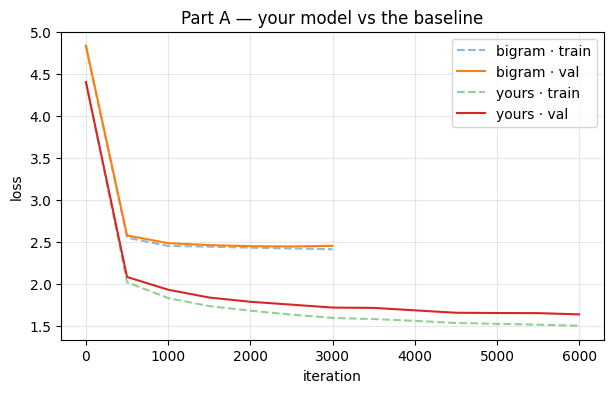


Athe Minister that we geliefal Alduge in allogies. I systioning roadly for oneoreed sorre will live a dubed it omp, are that strati? sitike Milling at was hap busp, bhis areasy, it shart that 105 harlith therend and va making mored:
Mr way. Rentinus to ofth an the recognise those faving?

Alling to uncilighnment preme phomicate wight con lights will be that the House easure is the North intely to 


In [48]:
final = P['estimate_loss'](model)
print(f"yours    | train {final['train']:.4f} | val {final['val']:.4f} | perplexity {math.exp(final['val']):.1f}")
print(f"baseline | val {baseline['val']:.4f} | perplexity {math.exp(baseline['val']):.1f}")

plot_histories({'bigram': bigram_history, 'yours': model_history},
               title='Part A — your model vs the baseline')

context = torch.zeros((1, 1), dtype=torch.long, device=device)
print(P['decode'](model.generate(context, max_new_tokens=400)[0].tolist()))

### Save and verify your checkpoint

Your submission is the notebook **plus** the `.pt` file the next cell saves. The verify cell after it runs the same checks we run on every submission. **If the verify cell passes for you, it will pass for us.** Download the .pt file from Colab's file browser (folder icon, left sidebar) when you are done.

In [49]:
# Save your checkpoint. Re-run this (and the verify cell) if you retrain your model.
bundle = dict(state_dict=model.state_dict(),
              block_size=P['block_size'],
              n_params=n_params,
              val_loss=final['val'])
torch.save(bundle, 'me324-midterm-checkpoint.pt')
print(f"saved me324-midterm-checkpoint.pt ({os.path.getsize('me324-midterm-checkpoint.pt')/1e6:.1f} MB)")

saved me324-midterm-checkpoint.pt (0.9 MB)


In [51]:
# Verify your submission — the same checks we run on receipt. Leave this cell in.
b = torch.load('me324-midterm-checkpoint.pt', map_location='cpu', weights_only=True)

n = sum(t.numel() for t in b['state_dict'].values())
assert n <= 500_000, f'over budget: {n:,}'

banned = [k for k in b['state_dict']
          if any(s in k.lower() for s in ('attn', 'attention', 'in_proj', 'q_proj', 'k_proj', 'v_proj'))]
assert not banned, f'attention-like modules found: {banned}'

check = MyLanguageModel(P['vocab_size'])         # constructor defaults must rebuild your shapes
check.load_state_dict(b['state_dict'])
check.to(device)

P_check = build_char_pipeline(text, block_size=b['block_size'], batch_size=32, device=device)
torch.manual_seed(1337)
recomputed = P_check['estimate_loss'](check)['val']
print(f"recomputed val {recomputed:.4f} | reported {b['val_loss']:.4f} | baseline {baseline['val']:.4f}")
assert abs(recomputed - b['val_loss']) < 0.05, 'reported loss does not match the checkpoint'
assert recomputed <= baseline['val'] - 0.1, 'does not beat the baseline by 0.1'
print('all submission checks passed')

recomputed val 1.6446 | reported 1.6403 | baseline 2.4415
all submission checks passed


✍️ **Design justification (~150 words).**
When creating my model, i was thinking in what way to incorporate previous text, without using a RNN, since i did not practice with that yet. Since the bigram model only uses the previous token, i thought about creating a long vector which contains the block length in tokens. This way we can use an entire block to predict the next character (this is a sliding-window model). From this onwards i could just apply techniques already known, such as Linear layers, RELU and dropout. This choice was arbitrary, i just wanted to check out what works well. The size of the embedding and linear layers are arbitrary however, i figured that itdb a good idea to get a power of 2 since that is used a lot and try to see if it is overfitting. My parameters, are spend on the level of embedding and the depth of my linear layers.


*Why this architecture, why these sizes, and what you spent your 500k parameters on. Your argument should be theoretical and specific. Replace this text with your answer.*

## Section 4 · Part B — Experimenting on your model (35 marks)

Pick **two** of the following hyperparameters and test them on your model, one at a time:

1. **Context length** — `block_size` (Lecture 8): a wider window conditions on more, but in a fixed-window model it costs parameters. Does the trade buy anything?
2. **Capacity** — hidden size, embedding size, or number of layers (depth vs width)
3. **Learning rate** — value or schedule (Lecture 4)
4. **Regularisation** — dropout or weight decay (Lecture 5)
5. **Batch size** (Lectures 4–5)
6. **Training length** — train much longer, and decide from the curves when you *should* have stopped (Lecture 5)

For each experiment, in this order:

- **State your hypothesis first**, in the ✍️ cell, *before* you run anything.
- **Run a fair comparison.**
- **Show the curves** with `plot_histories`.
- **Interpret** in the ✍️ cell: 150–250 words, referring to your actual numbers.

We will mark the reasoning and the fairness of the comparison, not whether the change helped.

### Experiment 1

✍️ **Hyperparameter:** *Context length for block-size=*

✍️ **Hypothesis (written before running):** *I would expect the validation loss to be decreasing in context length (block size), since the model would have more context in terms of window size. However, if the window gets too large it might be overfitting, because it didnt study text but memorized specific sentences.*

In [58]:
# I have vibecoded this

# --- Run 1: block_size = 8 (Standard) ---
P_bs8 = build_char_pipeline(text, block_size=8, batch_size=32, device=device)

torch.manual_seed(1337) # Ensure reproducibility
model_bs8 = MyLanguageModel(vocab_size=P_bs8['vocab_size'], block_size=8).to(device)
n_params_bs8 = count_params(model_bs8)
print(f'Model with block_size=8 parameters: {n_params_bs8:,}')

model_bs8, hist_bs8 = train_model_tracked(model_bs8, P_bs8['get_batch'], P_bs8['estimate_loss'],
                                           max_iters=3000, eval_interval=500, lr=1e-3,
                                           device=device)

# --- Run 2: block_size = 16 (Varied) ---
P_bs16 = build_char_pipeline(text, block_size=16, batch_size=32, device=device)

torch.manual_seed(1337) # Ensure reproducibility
model_bs16 = MyLanguageModel(vocab_size=P_bs16['vocab_size'], block_size=16).to(device)
n_params_bs16 = count_params(model_bs16)
print(f'\nModel with block_size=16 parameters: {n_params_bs16:,}')

model_bs16, hist_bs16 = train_model_tracked(model_bs16, P_bs16['get_batch'], P_bs16['estimate_loss'],
                                             max_iters=3000, eval_interval=500, lr=1e-3,
                                             device=device)

# --- Run 3: block_size = 24 (Varied) ---
P_bs24 = build_char_pipeline(text, block_size=24, batch_size=32, device=device)

torch.manual_seed(1337) # Ensure reproducibility
model_bs24 = MyLanguageModel(vocab_size=P_bs24['vocab_size'], block_size=24).to(device)
n_params_bs24 = count_params(model_bs24)
print(f'\nModel with block_size=24 parameters: {n_params_bs24:,}')

model_bs24, hist_bs24 = train_model_tracked(model_bs24, P_bs24['get_batch'], P_bs24['estimate_loss'],
                                             max_iters=3000, eval_interval=500, lr=1e-3,
                                             device=device)

# --- Run 3: block_size = 32 (Varied) ---
P_bs32 = build_char_pipeline(text, block_size=32, batch_size=32, device=device)

torch.manual_seed(1337) # Ensure reproducibility
model_bs32 = MyLanguageModel(vocab_size=P_bs32['vocab_size'], block_size=32).to(device)
n_params_bs32 = count_params(model_bs32)
print(f'\nModel with block_size=32 parameters: {n_params_bs32:,}')

model_bs32, hist_bs32 = train_model_tracked(model_bs32, P_bs32['get_batch'], P_bs32['estimate_loss'],
                                             max_iters=3000, eval_interval=500, lr=1e-3,
                                             device=device)

# --- Run 3: block_size = 64 (Varied) ---
P_bs64 = build_char_pipeline(text, block_size=64, batch_size=32, device=device)

torch.manual_seed(1337) # Ensure reproducibility
model_bs64 = MyLanguageModel(vocab_size=P_bs64['vocab_size'], block_size=64).to(device)
n_params_bs64 = count_params(model_bs64)
print(f'\nModel with block_size=24 parameters: {n_params_bs64:,}')

model_bs64, hist_bs64 = train_model_tracked(model_bs64, P_bs64['get_batch'], P_bs64['estimate_loss'],
                                             max_iters=3000, eval_interval=500, lr=1e-3,
                                             device=device)

Model with block_size=8 parameters: 155,571
step     0 | train 4.4231 | val 4.4233
step   500 | train 2.1326 | val 2.1851
step  1000 | train 1.9972 | val 2.0693
step  1500 | train 1.9153 | val 1.9925
step  2000 | train 1.8560 | val 1.9437
step  2500 | train 1.8237 | val 1.9235
step  2999 | train 1.7904 | val 1.8884

Model with block_size=16 parameters: 221,107
step     0 | train 4.4039 | val 4.4044
step   500 | train 2.0233 | val 2.0869
step  1000 | train 1.8322 | val 1.9289
step  1500 | train 1.7351 | val 1.8363
step  2000 | train 1.6824 | val 1.7880
step  2500 | train 1.6344 | val 1.7500
step  2999 | train 1.5975 | val 1.7200

Model with block_size=24 parameters: 286,643
step     0 | train 4.4167 | val 4.4170
step   500 | train 1.9776 | val 2.0504
step  1000 | train 1.7715 | val 1.8674
step  1500 | train 1.6628 | val 1.7776
step  2000 | train 1.5932 | val 1.7274
step  2500 | train 1.5563 | val 1.6926
step  2999 | train 1.5240 | val 1.6622

Model with block_size=32 parameters: 352,179

In [17]:
# TODO: label your runs and plot them against each other.
# plot_histories({'setting A': hist_a, 'setting B': hist_b}, title='Experiment 1')

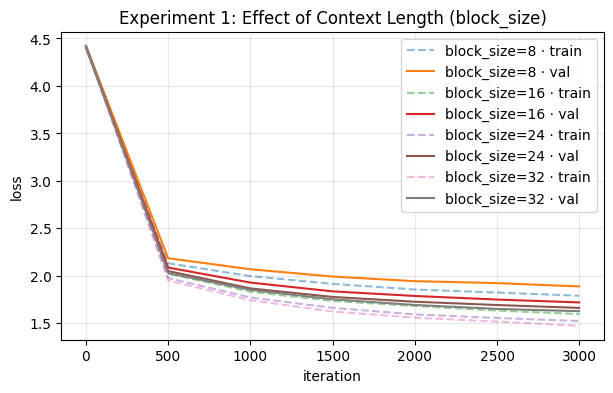

In [60]:
# Plot the training histories for comparison
plot_histories({'block_size=8': hist_bs8, 'block_size=16': hist_bs16, 'block_size=24': hist_bs24, 'block_size=32': hist_bs32}, title='Experiment 1: Effect of Context Length (block_size)')

✍️ **Interpretation (150–250 words).** *What happened, was your hypothesis right, and
what in the curves tells you? Replace this text with your answer.*

### Experiment 2

✍️ **Hyperparameter:** *Training length*

✍️ **Hypothesis (written before running):** *I would expect the validation loss to decrease in longer training time, however for larger block sizes i would think that the model starts to overfit more quickly. That is why i will check it on 16 block size*

In [61]:
# --- Run 1: block_size = 16, Standard Training Length (15000 iterations) ---
P_e2_std = build_char_pipeline(text, block_size=12, batch_size=32, device=device)

torch.manual_seed(1337) # Ensure reproducibility
model_e2_std = MyLanguageModel(vocab_size=P_e2_std['vocab_size'], block_size=16).to(device)
n_params_e2_std = count_params(model_e2_std)
print(f'Model (block_size=16, 15000 iters) parameters: {n_params_e2_std:,}')

model_e2_std, hist_e2_std = train_model_tracked(model_e2_std, P_e2_std['get_batch'], P_e2_std['estimate_loss'],
                                                        max_iters=15000, eval_interval=500, lr=1e-3,
                                                        device=device)

Model (block_size=16, 15000 iters) parameters: 221,107
step     0 | train 4.3998 | val 4.4006
step   500 | train 2.0894 | val 2.1444
step  1000 | train 1.9030 | val 2.0080
step  1500 | train 1.8093 | val 1.9244
step  2000 | train 1.7576 | val 1.8709
step  2500 | train 1.7270 | val 1.8221
step  3000 | train 1.6717 | val 1.7912
step  3500 | train 1.6627 | val 1.7795
step  4000 | train 1.6426 | val 1.7525
step  4500 | train 1.6115 | val 1.7324
step  5000 | train 1.6031 | val 1.7129
step  5500 | train 1.5915 | val 1.7074
step  6000 | train 1.5807 | val 1.6992
step  6500 | train 1.5566 | val 1.6873
step  7000 | train 1.5614 | val 1.6758
step  7500 | train 1.5542 | val 1.6707
step  8000 | train 1.5438 | val 1.6787
step  8500 | train 1.5418 | val 1.6674
step  9000 | train 1.5441 | val 1.6615
step  9500 | train 1.5224 | val 1.6688
step 10000 | train 1.5211 | val 1.6555
step 10500 | train 1.5145 | val 1.6556
step 11000 | train 1.5045 | val 1.6469
step 11500 | train 1.5014 | val 1.6534
step 1200

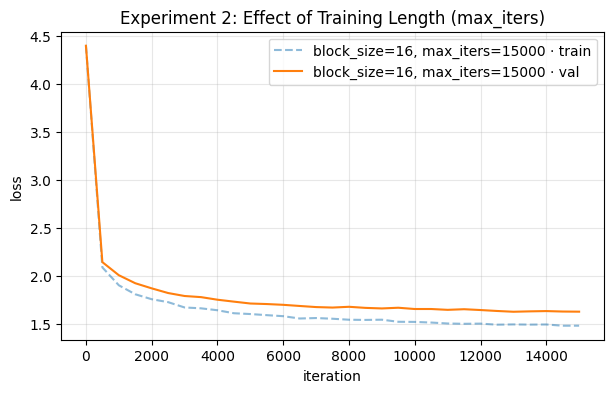

In [64]:
# Plot the training histories for comparison
plot_histories({'block_size=16, max_iters=15000': hist_e2_std}, title='Experiment 2: Effect of Training Length (max_iters)')

✍️ **Interpretation (150–250 words).** *What happened, was your hypothesis right, and
what in the curves tells you? Replace this text with your answer.*

## Section 5 · Part C — Discussing your model (25 marks)

Provide three short answers, ~200 words each, referencing your results — make sure to quote your own numbers and samples, not general facts about language models.

**C1 · Diagnose your final model** using the Lecture 5 taxonomy: underfitting,
overfitting, or about right? Argue from your train/validation curves. Then: what would
you try first with ten times the compute, and why that rather than something else?

✍️ *Replace this text with your answer (~200 words).*

**C2 · Take two or three generated samples.** What has the model genuinely learned about parliamentary English — structure, register, names, procedure? What does it consistently get wrong, and which limitation from the lectures explains that failure?

✍️ *Replace this text with your answer (~200 words).*

**C3 · The data.** Your training data is real MPs' words, scraped from the public record (published under the Open Parliament Licence, which permits this). Give one reason this use is clearly legitimate, and one genuine concern that would apply to training on scraped text in general.

✍️ *Replace this text with your answer (~200 words).*

## Appendix — AI use (5 marks, with reporting)

✍️ **Tools.** *Which AI assistants you used, and for what (writing code, debugging,
explaining, drafting prose). "None" is acceptable, but we don't expect it.*

I have used Gemini to debug my code and vibecode the code for the experiment section.

✍️ **One correction.** *Paste one exchange where an assistant's suggestion was wrong, or
didn't fit the rules or the budget, and explain how you caught and fixed it. If you never
had to correct anything, pick one substantial piece of assistant-written code and explain
how you satisfied yourself it was right.*

I had modeled by myself at the start a model which basically tried to predict the upcoming characters, however it would be able to see the "solutions" already. So I tried to predict characters x_{n+1}, ..., x_{n+bs+1} from x_{n}, ..., x_{n+bs}. So when predicting x_{n+1} I could already observe it. That is why I got a very low validation loss but bad performance at the start. I was confused so I asked Gemini and it was not able to find the problem. A friend suggested putting it in Claude and it spotted the problem, then I fixed it using Claude.

✍️ **Declaration.** *"I can explain every line of this notebook." Leave this line in —
submitting the notebook asserts it.*

## Before you submit

- [ ] Runtime → **Restart and run all** completes without errors, in under ~20 minutes on a Colab GPU runtime
- [ ] All cell outputs visible and saved — do **not** clear outputs
- [ ] The parameter assert and the **verify cell** both pass on the fresh run
- [ ] Checkpoint downloaded from the Colab file browser
- [ ] Every ✍️ cell filled in (and both hypotheses genuinely written before the runs)
- [ ] Appendix complete
- [ ] **Two files**, renamed `ME324-midterm-<candidate-number>.ipynb` and `ME324-midterm-<candidate-number>.pt`, uploaded to Moodle by **09:00, Tuesday 18 August**